# Pilot 3 - second method + confidence scheme

Until now everything was tag-only (heuristic **H1**). This notebook adds the
second method — **payout-address matching (H2)** — and combines the two into a
confidence scheme:

| tag match | address match | result |
|---|---|---|
| both agree | | **HIGH** |
| both match, disagree | | **CONFLICT** (the Romiti-style conflict) |
| tag only | | TAG_ONLY |
| address only | | ADDR_ONLY |
| neither | | UNKNOWN |


In [12]:
%matplotlib inline
import json, os
import collections
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT_ID = "project-9536b219-93fb-4fca-aac"   
client = bigquery.Client(project=PROJECT_ID)

# load BOTH sections of the reference list (note encoding="utf-8" — Windows)
pools = json.load(open("../data/raw/pools.json", encoding="utf-8"))
coinbase_tags = pools["coinbase_tags"]
payout_addresses = pools["payout_addresses"]
TAGS = sorted(coinbase_tags.items(), key=lambda kv: len(kv[0]), reverse=True)
print(f"{len(coinbase_tags)} tags, {len(payout_addresses)} payout addresses loaded")

149 tags, 190 payout addresses loaded


## Step 1 - pull coinbase tag AND output addresses

We now need the payout addresses, which live in the `transactions` table, so we
join it to `blocks` (which holds the tag). To keep the scan small, we restrict to
**one month**. Change the two dates to move or widen the window.

In [13]:
QUERY = """
SELECT
  b.number AS height,
  b.timestamp,
  b.coinbase_param,
  ARRAY(
    SELECT addr FROM UNNEST(t.outputs) AS o, UNNEST(o.addresses) AS addr
  ) AS output_addresses
FROM `bigquery-public-data.crypto_bitcoin.blocks` AS b
JOIN `bigquery-public-data.crypto_bitcoin.transactions` AS t
  ON t.block_number = b.number
WHERE t.is_coinbase = TRUE
  AND t.block_timestamp >= TIMESTAMP('2021-06-01')   -- window start
  AND t.block_timestamp <  TIMESTAMP('2021-07-01')   -- window end
  AND b.timestamp        >= TIMESTAMP('2021-06-01')
  AND b.timestamp        <  TIMESTAMP('2021-07-01')
ORDER BY b.number
"""

dry = client.query(QUERY, bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
gb = dry.total_bytes_processed / 1e9
print(f"will scan ~{gb:.2f} GB.  Free tier = 1000 GB/month.")
assert gb < 30, "Bigger than expected — shrink the window before running."

will scan ~182.97 GB.  Free tier = 1000 GB/month.


AssertionError: Bigger than expected — shrink the window before running.

In [14]:
blocks_df = client.query(QUERY).to_dataframe()
print("shape:", blocks_df.shape)
blocks_df.head(3)

C:\Users\Nakis\Documents\Thesis Papers\Thesis\bitcoin-decentralisation\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


shape: (3538, 4)


,height,timestamp,coinbase_param,output_addresses
0,685719,2021-06-01 00:08:07+00:00,0397760a04547ab5602f706f6f6c696e2e636f6d2f7461...,"[191sNkKTG8pzUsNgZYKo7DH2odg39XDAGo, nonstanda..."
1,685720,2021-06-01 00:44:04+00:00,0398760a192f5669614254432f4d696e6564206279206a...,"[18cBEMRxXHqzWWCxZNtU91F5sbUNKhL5PX, nonstanda..."
2,685721,2021-06-01 00:53:42+00:00,0399760a1b4d696e656420627920416e74506f6f6c3737...,"[12dRugNcdxK39288NjcDV4GX7rMsKCGn6B, nonstanda..."


## Step 2 — run both methods

In [15]:
def decode_coinbase(hex_str):
    if not hex_str:
        return ""
    try:
        return bytes.fromhex(hex_str).decode("utf-8", errors="ignore")
    except (ValueError, TypeError):
        return str(hex_str)

def match_by_tag(text):
    for tag, meta in TAGS:           # longest tag first
        if tag in text:
            return meta["name"]
    return None

def match_by_address(addr_list):
    if addr_list is None or len(addr_list) == 0:
        return None
    names = [payout_addresses[a]["name"] for a in addr_list if a in payout_addresses]
    if not names:
        return None
    return collections.Counter(names).most_common(1)[0][0]

blocks_df["coinbase_text"] = blocks_df["coinbase_param"].apply(decode_coinbase)
blocks_df["tag_pool"]  = blocks_df["coinbase_text"].apply(match_by_tag)
blocks_df["addr_pool"] = blocks_df["output_addresses"].apply(match_by_address)

## Step 3 - how much does each method cover?

Tag and address matching catch different blocks. Where they overlap is where the
confidence scheme can corroborate, or disagree.


In [16]:
n = len(blocks_df)
tag_cov  = blocks_df["tag_pool"].notna().mean()
addr_cov = blocks_df["addr_pool"].notna().mean()
either   = (blocks_df["tag_pool"].notna() | blocks_df["addr_pool"].notna()).mean()
both     = (blocks_df["tag_pool"].notna() & blocks_df["addr_pool"].notna()).mean()
print(f"blocks: {n}")
print(f"tag matched:        {tag_cov:.1%}")
print(f"address matched:    {addr_cov:.1%}")
print(f"either method:      {either:.1%}")
print(f"both methods:       {both:.1%}")

blocks: 3538
tag matched:        89.7%
address matched:    66.1%
either method:      99.5%
both methods:       56.4%


## Step 4- confidence scheme + the conflict rate

The headline number is the **conflict rate**: of the blocks where
both methods fired, how often do they name *different* pools? That disagreement,
which Romiti et al. found 684 of across the whole chain ,is the AMBIGUOUS tier,
and it only exists once you have two methods.

In [17]:
import numpy as np

tag  = blocks_df["tag_pool"]
addr = blocks_df["addr_pool"]
has_tag, has_addr = tag.notna(), addr.notna()

blocks_df["confidence"] = np.select(
    [has_tag & has_addr & (tag == addr),
     has_tag & has_addr & (tag != addr),
     has_tag & ~has_addr,
     ~has_tag & has_addr],
    ["HIGH", "CONFLICT", "TAG_ONLY", "ADDR_ONLY"],
    default="UNKNOWN",
)
# final label: tag if present, else address, else unknown (tag-preferred = one H5 choice)
blocks_df["pool"] = np.where(has_tag, tag, np.where(has_addr, addr, "unknown"))

print(blocks_df["confidence"].value_counts().to_string())

both = blocks_df[has_tag & has_addr]
n_conf = int((both["confidence"] == "CONFLICT").sum())
if len(both):
    print(f"\nconflict rate: {n_conf}/{len(both)} both-matched blocks ({n_conf/len(both):.1%})")
print("\nexample conflicts (tag says X, address says Y):")
print(both.loc[both["confidence"] == "CONFLICT",
               ["height", "tag_pool", "addr_pool"]].head().to_string(index=False))

confidence
HIGH         1994
TAG_ONLY     1181
ADDR_ONLY     346
UNKNOWN        17

conflict rate: 0/1994 both-matched blocks (0.0%)

example conflicts (tag says X, address says Y):
Empty DataFrame
Columns: [height, tag_pool, addr_pool]
Index: []


## Step 5 — tier breakdown

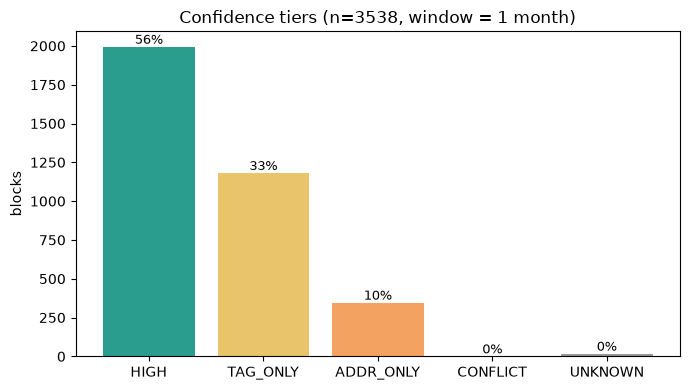

In [18]:
order = ["HIGH", "TAG_ONLY", "ADDR_ONLY", "CONFLICT", "UNKNOWN"]
tiers = blocks_df["confidence"].value_counts().reindex(order).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"HIGH":"#2a9d8f","TAG_ONLY":"#e9c46a","ADDR_ONLY":"#f4a261",
          "CONFLICT":"#e76f51","UNKNOWN":"#999999"}
ax.bar(tiers.index, tiers.values, color=[colors[t] for t in tiers.index])
ax.set_ylabel("blocks")
ax.set_title(f"Confidence tiers (n={len(blocks_df)}, window = 1 month)")
for i, v in enumerate(tiers.values):
    ax.text(i, v, f"{v/len(blocks_df):.0%}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/pilot3_tiers.png", dpi=120, bbox_inches="tight")
plt.show()

## What was built 

**D2** heuristics:
- **H1** = tag only (ignore the address column)
- **H2** = address only
- **H3** = union — count a block as known if *either* method matched
- **H4** = intersection — only HIGH (both agree) counts as known
- **H5** = a rule for resolving CONFLICT (e.g. prefer the address)




